# Pipeline Adaptive Threshold Walk-Forward

This notebook is the long-history, notebook-style version of adaptive daily threshold simulation.

It is meant to feel closer to your `PipelineCode.ipynb` workflow, but the online threshold decisions are trained from the per-day 5-minute reward table in `daily_bandit_log.csv`.

That means:
- the threshold policy is learned online
- the reward target comes from the 5-minute engine results
- the decision logic matches your intended rule:
  - `FORCE_BUY` should correspond to `p_day < buy_level`
  - `FREE` should correspond to `buy_level <= p_day <= sell_level`
  - `FORCE_SELL` should correspond to `p_day > sell_level`


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from adaptive_trade_extensions import (
    RollingThresholdConfig,
    ThresholdPairBandit,
    ThresholdPairBanditConfig,
    make_threshold_grid,
    run_walkforward_threshold_policy,
    run_walkforward_threshold_bandit_policy,
)

ROOT = Path.cwd()
bandit_logs = sorted(ROOT.glob('output*/daily_bandit_log.csv'), key=lambda p: p.stat().st_mtime, reverse=True)
print(f'daily_bandit_log files found: {len(bandit_logs)}')
for i, p in enumerate(bandit_logs[:20]):
    print(f'[{i}] {p}')

daily_bandit_log files found: 5
[0] c:\Users\TonyTang\Documents\chan.py\output_QQQ_realtime_exact_2008_2017\daily_bandit_log.csv
[1] c:\Users\TonyTang\Documents\chan.py\output_QQQ_realtime_exact_2019_2021\daily_bandit_log.csv
[2] c:\Users\TonyTang\Documents\chan.py\output_stage1_2013_2019_leakfree_realfree\daily_bandit_log.csv
[3] c:\Users\TonyTang\Documents\chan.py\output_stage1_2013_2019\daily_bandit_log.csv
[4] c:\Users\TonyTang\Documents\chan.py\output_daily_bandit_5m_xgb_adaptive_QQQ\daily_bandit_log.csv


In [2]:
# ------------------------------------------------------------
# Pick the long-history run you want to replay online.
# Good examples in your repo include:
#   output_QQQ_realtime_exact_2008_2017/daily_bandit_log.csv
#   output_QQQ_realtime_exact_2019_2021/daily_bandit_log.csv
# ------------------------------------------------------------

selected_idx = 0
daily_bandit_log_path = bandit_logs[selected_idx]
daily_bandit_log_path

WindowsPath('c:/Users/TonyTang/Documents/chan.py/output_QQQ_realtime_exact_2008_2017/daily_bandit_log.csv')

In [3]:
df = pd.read_csv(daily_bandit_log_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df.head()

,date,chosen_action,reward_force_buy,reward_free,reward_force_sell,chosen_reward,best_action_ex_post,oracle_equity,p_day,close
0,2012-01-03,FORCE_BUY,0.003173,0.003702,0.000000,0.003173,FREE,100370.184099,0.242042,56.90
1,2012-01-04,FREE,0.005982,0.002099,-0.000704,0.002099,FORCE_BUY,100970.568733,0.237409,57.14
2,2012-01-05,FORCE_SELL,0.000000,0.000000,0.000000,0.000000,FORCE_BUY,100970.568733,0.230725,57.61
3,2012-01-06,FORCE_BUY,0.000000,0.000000,0.000000,0.000000,FORCE_BUY,100970.568733,0.241758,57.81
4,2012-01-09,FREE,0.000000,0.000000,0.000000,0.000000,FORCE_BUY,100970.568733,0.224054,57.62


In [4]:
required = ['date', 'p_day', 'reward_force_buy', 'reward_free', 'reward_force_sell']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

print('rows =', len(df))
print('date range =', df['date'].min(), '->', df['date'].max())
display(df[required + [c for c in ['best_action_ex_post', 'chosen_action', 'oracle_equity'] if c in df.columns]].head())

rows = 1509
date range = 2012-01-03 00:00:00 -> 2017-12-29 00:00:00


,date,p_day,reward_force_buy,reward_free,reward_force_sell,best_action_ex_post,chosen_action,oracle_equity
0,2012-01-03,0.242042,0.003173,0.003702,0.000000,FREE,FORCE_BUY,100370.184099
1,2012-01-04,0.237409,0.005982,0.002099,-0.000704,FORCE_BUY,FREE,100970.568733
2,2012-01-05,0.230725,0.000000,0.000000,0.000000,FORCE_BUY,FORCE_SELL,100970.568733
3,2012-01-06,0.241758,0.000000,0.000000,0.000000,FORCE_BUY,FORCE_BUY,100970.568733
4,2012-01-09,0.224054,0.000000,0.000000,0.000000,FORCE_BUY,FREE,100970.568733


## Static Baseline

This reproduces the fixed-threshold style you currently use, such as `0.20 / 0.30`.

In [5]:
from adaptive_trade_extensions import gate_from_levels, realized_reward_for_gate

static_buy = 0.20
static_sell = 0.30
initial_equity = 100000.0

static_rows = []
equity = initial_equity
for _, row in df.iterrows():
    gate = gate_from_levels(float(row['p_day']), static_buy, static_sell)
    reward = realized_reward_for_gate(row, gate)
    equity *= (1.0 + reward)
    static_rows.append({
        'date': row['date'],
        'p_day': float(row['p_day']),
        'buy_level': static_buy,
        'sell_level': static_sell,
        'gate': gate,
        'reward': reward,
        'equity': equity,
    })

static_df = pd.DataFrame(static_rows)
static_df.tail()

,date,p_day,buy_level,sell_level,gate,reward,equity
1504,2017-12-22,0.206049,0.2,0.3,FREE,-0.000381,279927.514913
1505,2017-12-26,0.208487,0.2,0.3,FREE,-0.002069,279348.300418
1506,2017-12-27,0.202816,0.2,0.3,FREE,0.000319,279437.440855
1507,2017-12-28,0.198124,0.2,0.3,FORCE_BUY,0.000000,279437.440855
1508,2017-12-29,0.274607,0.2,0.3,FREE,-0.009686,276730.680021


## Adaptive Rolling Threshold Policy

This is the online threshold optimizer. It only uses past daily 5-minute rewards, never future rows.

In [6]:
cfg = RollingThresholdConfig(
    lookback_days=252,
    buy_grid=make_threshold_grid(0.05, 0.35, 0.005),
    sell_grid=make_threshold_grid(0.15, 0.60, 0.005),
    min_gap=0.02,
    min_obs=60,
    switch_penalty=0.0,
)

adaptive_reward_df = run_walkforward_threshold_policy(
    daily_rewards_df=df,
    config=cfg,
    initial_equity=initial_equity,
    objective='reward',
    default_buy_level=0.20,
    default_sell_level=0.30,
)

adaptive_reward_df.tail()

,date,p_day,buy_level,sell_level,gate,reward,equity,best_action_ex_post,oracle_best_reward,fit_score,fit_window
1504,2017-12-22,0.206049,0.255,0.275,FORCE_BUY,-0.000381,336656.653888,FORCE_SELL,0.000000,0.374670,252
1505,2017-12-26,0.208487,0.255,0.275,FORCE_BUY,-0.002420,335841.919915,FREE,-0.002069,0.376367,252
1506,2017-12-27,0.202816,0.255,0.275,FORCE_BUY,0.000255,335927.654019,FREE,0.000319,0.371445,252
1507,2017-12-28,0.198124,0.245,0.265,FORCE_BUY,0.000000,335927.654019,FORCE_BUY,0.000000,0.370814,252
1508,2017-12-29,0.274607,0.245,0.265,FORCE_SELL,0.000000,335927.654019,FORCE_SELL,0.000000,0.370814,252


In [7]:
# ------------------------------------------------------------
# Same online simulation, but optimize threshold agreement with the
# ex-post best action instead of raw realized reward.
# ------------------------------------------------------------

adaptive_accuracy_df = run_walkforward_threshold_policy(
    daily_rewards_df=df,
    config=cfg,
    initial_equity=initial_equity,
    objective='accuracy',
    default_buy_level=0.20,
    default_sell_level=0.30,
)

adaptive_accuracy_df.tail()

,date,p_day,buy_level,sell_level,gate,reward,equity,best_action_ex_post,oracle_best_reward,fit_score,fit_window
1504,2017-12-22,0.206049,0.255,0.275,FORCE_BUY,-0.000381,380510.641364,FORCE_SELL,0.000000,0.571429,252
1505,2017-12-26,0.208487,0.255,0.275,FORCE_BUY,-0.002420,379589.777502,FREE,-0.002069,0.571429,252
1506,2017-12-27,0.202816,0.255,0.275,FORCE_BUY,0.000255,379686.679608,FREE,0.000319,0.571429,252
1507,2017-12-28,0.198124,0.250,0.270,FORCE_BUY,0.000000,379686.679608,FORCE_BUY,0.000000,0.567460,252
1508,2017-12-29,0.274607,0.250,0.270,FORCE_SELL,0.000000,379686.679608,FORCE_SELL,0.000000,0.571429,252


## Threshold-Pair Bandit Policy

This is the RL-style version where the action is the threshold pair, not directly the gate.

In [8]:
bandit = ThresholdPairBandit(
    n_features=6,
    config=ThresholdPairBanditConfig(
        threshold_pairs=[
            (0.10, 0.22),
            (0.12, 0.24),
            (0.15, 0.25),
            (0.18, 0.28),
            (0.20, 0.30),
            (0.22, 0.32),
            (0.25, 0.35),
        ],
        alpha=0.50,
        l2=1.0,
    ),
)

bandit_df = run_walkforward_threshold_bandit_policy(
    daily_rewards_df=df,
    bandit=bandit,
    initial_equity=initial_equity,
)

bandit_df.tail()

,date,p_day,buy_level,sell_level,gate,reward,equity,best_action_ex_post,oracle_best_reward
1504,2017-12-22,0.206049,0.15,0.25,FREE,-0.000381,317441.464771,FORCE_SELL,0.000000
1505,2017-12-26,0.208487,0.10,0.22,FREE,-0.002069,316784.627955,FREE,-0.002069
1506,2017-12-27,0.202816,0.18,0.28,FREE,0.000319,316885.714377,FREE,0.000319
1507,2017-12-28,0.198124,0.22,0.32,FORCE_BUY,0.000000,316885.714377,FORCE_BUY,0.000000
1508,2017-12-29,0.274607,0.20,0.30,FREE,-0.009686,313816.212173,FORCE_SELL,0.000000


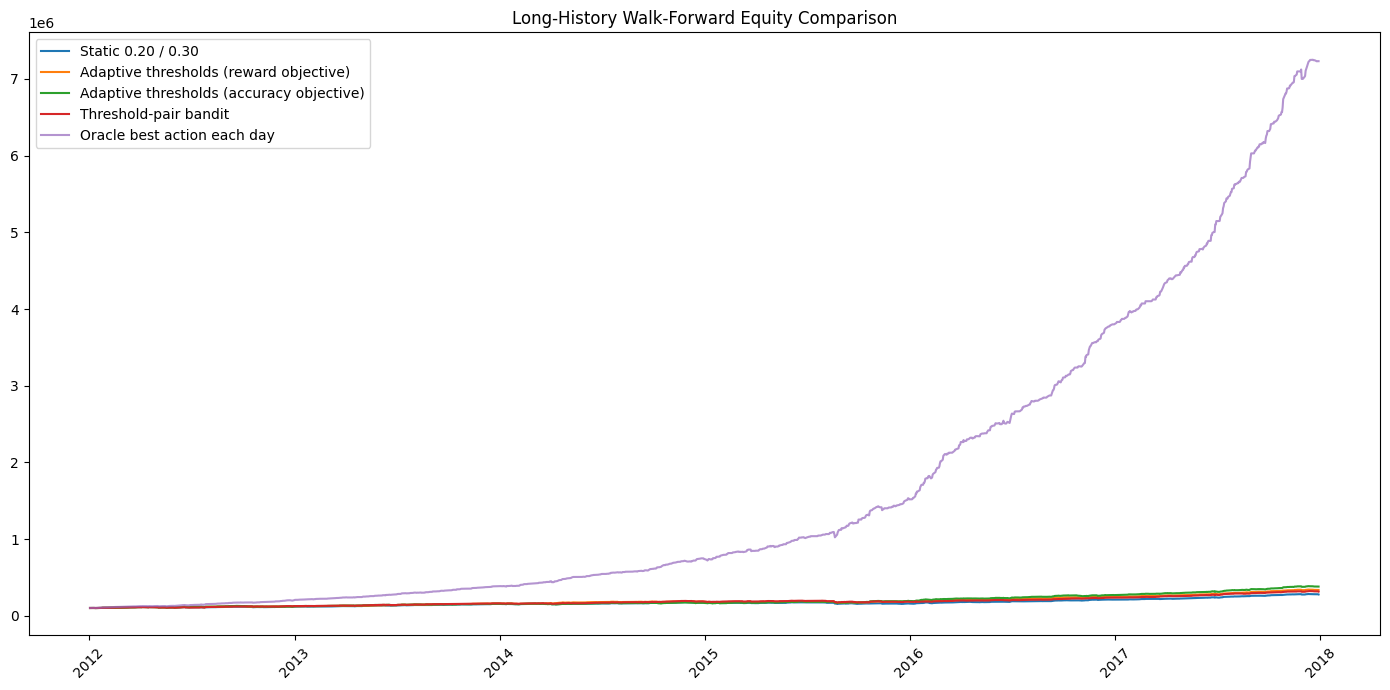

In [9]:
# ------------------------------------------------------------
# Equity comparison
# ------------------------------------------------------------

oracle_equity = initial_equity
oracle_rows = []
for _, row in df.iterrows():
    best_reward = max(float(row['reward_force_buy']), float(row['reward_free']), float(row['reward_force_sell']))
    oracle_equity *= (1.0 + best_reward)
    oracle_rows.append({'date': row['date'], 'equity': oracle_equity})
oracle_df = pd.DataFrame(oracle_rows)

plt.figure(figsize=(14, 7))
plt.plot(static_df['date'], static_df['equity'], label='Static 0.20 / 0.30')
plt.plot(adaptive_reward_df['date'], adaptive_reward_df['equity'], label='Adaptive thresholds (reward objective)')
plt.plot(adaptive_accuracy_df['date'], adaptive_accuracy_df['equity'], label='Adaptive thresholds (accuracy objective)')
plt.plot(bandit_df['date'], bandit_df['equity'], label='Threshold-pair bandit')
plt.plot(oracle_df['date'], oracle_df['equity'], label='Oracle best action each day', alpha=0.7)
plt.legend()
plt.title('Long-History Walk-Forward Equity Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

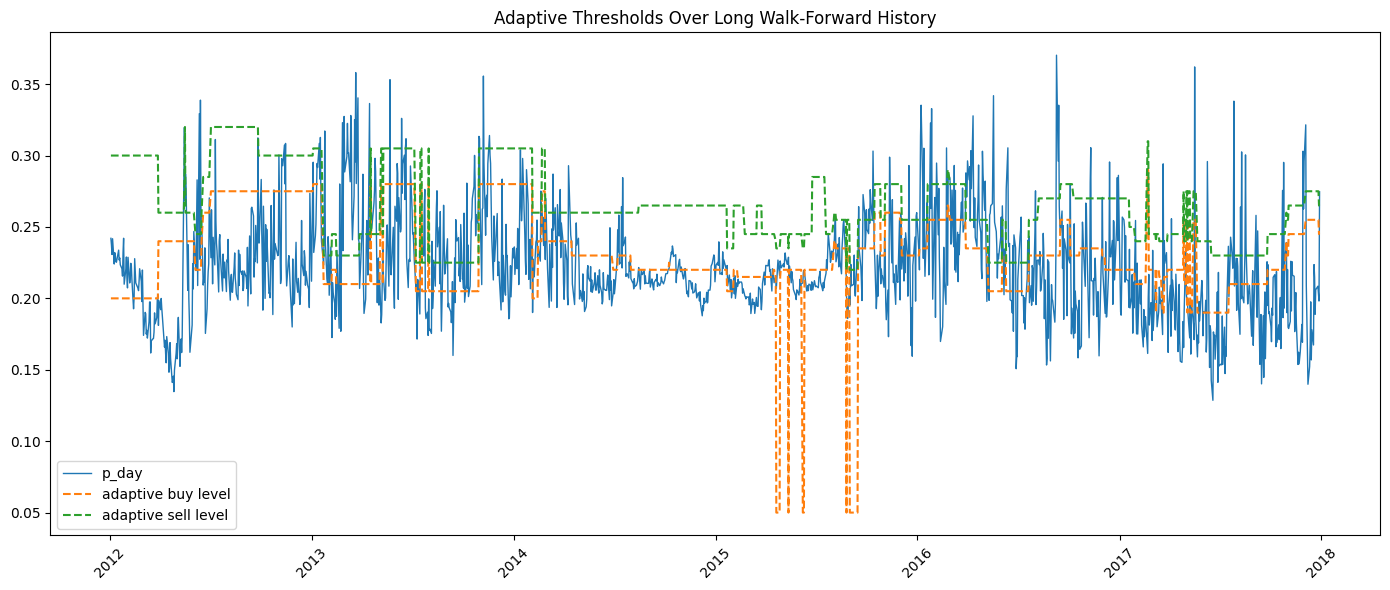

In [10]:
# ------------------------------------------------------------
# Inspect how thresholds move over time
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.plot(adaptive_reward_df['date'], adaptive_reward_df['p_day'], label='p_day', linewidth=1.0)
plt.plot(adaptive_reward_df['date'], adaptive_reward_df['buy_level'], label='adaptive buy level', linestyle='--')
plt.plot(adaptive_reward_df['date'], adaptive_reward_df['sell_level'], label='adaptive sell level', linestyle='--')
plt.legend()
plt.title('Adaptive Thresholds Over Long Walk-Forward History')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# ------------------------------------------------------------
# Action diagnostics
# ------------------------------------------------------------

def summarize_actions(df_in: pd.DataFrame, label: str):
    out = df_in['gate'].value_counts(normalize=True).rename(label)
    return out

summary = pd.concat([
    summarize_actions(static_df, 'static'),
    summarize_actions(adaptive_reward_df, 'adaptive_reward'),
    summarize_actions(adaptive_accuracy_df, 'adaptive_accuracy'),
    summarize_actions(bandit_df, 'bandit'),
], axis=1).fillna(0.0)

summary

,static,adaptive_reward,adaptive_accuracy,bandit
gate,,,,
FREE,0.720345,0.221339,0.086812,0.595096
FORCE_BUY,0.241882,0.631544,0.869450,0.253148
FORCE_SELL,0.037773,0.147117,0.043738,0.151756


In [12]:
# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

save_dir = ROOT / 'output' / 'adaptive_threshold_walkforward'
save_dir.mkdir(parents=True, exist_ok=True)

static_df.to_csv(save_dir / 'static_threshold_policy.csv', index=False)
adaptive_reward_df.to_csv(save_dir / 'adaptive_threshold_reward_policy.csv', index=False)
adaptive_accuracy_df.to_csv(save_dir / 'adaptive_threshold_accuracy_policy.csv', index=False)
bandit_df.to_csv(save_dir / 'threshold_pair_bandit_policy.csv', index=False)
oracle_df.to_csv(save_dir / 'oracle_daily_best.csv', index=False)

summary_payload = {
    'source_daily_bandit_log': str(daily_bandit_log_path),
    'initial_equity': initial_equity,
    'static_final_equity': float(static_df['equity'].iloc[-1]),
    'adaptive_reward_final_equity': float(adaptive_reward_df['equity'].iloc[-1]),
    'adaptive_accuracy_final_equity': float(adaptive_accuracy_df['equity'].iloc[-1]),
    'bandit_final_equity': float(bandit_df['equity'].iloc[-1]),
    'oracle_final_equity': float(oracle_df['equity'].iloc[-1]),
}

with open(save_dir / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_payload, f, indent=2)

summary_payload

{'source_daily_bandit_log': 'c:\\Users\\TonyTang\\Documents\\chan.py\\output_QQQ_realtime_exact_2008_2017\\daily_bandit_log.csv',
 'initial_equity': 100000.0,
 'static_final_equity': 276730.680020971,
 'adaptive_reward_final_equity': 335927.6540190746,
 'adaptive_accuracy_final_equity': 379686.6796084934,
 'bandit_final_equity': 313816.212173054,
 'oracle_final_equity': 7232389.256482533}